This file demonstrates the implementation of SHARV and ASHARV from my paper: A Simple Joint Model of Returns, Volatility and Volatility of Volatility,
Journal of Econometrics, 2023

The two models I proposed are called Stochastic Heteroskedastic AutoRegressive Volatility (SHARV) model and its asymmetric extension ASHARV model

In [1]:
from SHARV_class import *
from Utilities import *
import matplotlib.pyplot as plt
from arch import arch_model

In [2]:
data = pd.read_excel('Data/DJI.xlsx')
data['Date'] = pd.to_datetime(data['Date'], unit='D', origin='1899-12-30')
data.set_index('Date', inplace=True)

data = data.dropna()
# Log return
data['Close'] = np.log(data['Close']).diff() * 100

y = data[['Close']].dropna()

Using Dow Jones daily return as an example, convert the data to log return in percentage for numerical convenience. The maximum likelihood procedure is implemented in Cython file loglike.pyx, which utilizes C maths for the calculation. Please compile and set up accordingly (see read me)

The Sharv model is defined as:
$$\begin{align}
    &r_t = \sigma_t\epsilon_t, \\
    &\sigma_t^2 = \beta \sigma_{t-1}^2   + (\alpha + \psi\sigma_{t-1}^2) \epsilon_t^2,
\end{align}$$
where $\epsilon_t$ are i.i.d. $(0, 1)$

While the asymmetric extension ASHARV is given by:
$$\begin{align}
    &r_t = \mu\sigma_{t-1} + \sigma_t\epsilon_t, \\
    &\sigma_t^2 = \beta \sigma_{t-1}^2 + (\alpha + \psi\sigma_{t-1}^2)\epsilon_t^2 + (\omega + \phi\sigma_{t-1}^2)(\epsilon_t^{-})^2,
\end{align}$$
where $x^- = \min(x, 0)$.

We will use $\epsilon \sim N(0, 1)$ for parameter estimation purposes. Even if the true $\epsilon_t$ are not Normal, the standard quasi maximum likelihood (QML) theory states that the parameter estimators are still consistent under mild conditions

In [8]:
# Fit the sharv model
sharv_res = Sharv(y).fit()
# Asymmetric version
asharv_res = Sharv(y, asymmetry=True).fit()
# Benchmark model
garch = arch_model(y, mean="Zero", p=1, o=0, q=1).fit(disp=0)

print(f'SHARV: {pd.Series(sharv_res.params)}')
print(f'ASHARV: {pd.Series(asharv_res.params)}')
print(f'GARCH: {garch.params}')

SHARV: 0    0.876446
1    0.013226
2    0.110071
dtype: float64
ASHARV: 0    0.098732
1    0.894845
2    0.008778
3    0.000001
4    0.011841
5    0.188348
dtype: float64
GARCH: omega       0.020859
alpha[1]    0.122949
beta[1]     0.861343
Name: params, dtype: float64


Next, I will show that even with $\epsilon_t \sim N(0, 1)$, the conditional density of $r_t$ still has fat tails and skewness (under ASHARV)
Recall the conditional density of (A)SHARV is given by:
$$    f_r(y|\mathcal{F}_{t-1}) = \frac{y}{d_1(y, \sigma_{t-1}^2; \theta)d_2(y, \sigma_{t-1}^2; \theta)} f_\epsilon\big(d_2(y, \sigma_{t-1}^2; \theta)\big), \ \text{for $y \neq 0$}$$
where
$$    d_1(y, \sigma_{t-1}^2; \theta) = \sqrt{b_{t-1}^2+4a_{t-1}y^2+4c_{t-1}(y^-)^2},$$
$$    d_2(y, \sigma_{t-1}^2; \theta) =
    \begin{cases}
    sign(y)\sqrt{\dfrac{d_1(y, \sigma_{t-1}^2; \theta)-b_{t-1}}{2a_{t-1}+2c_{t-1}1_{(y<0)}}}, \ \ \ \text{if $(\alpha, \psi, \omega, \phi)^{'} \neq 0$} \\
    \ y/\sqrt{b_{t-1}},\ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \    \text{if $(\alpha, \psi, \omega, \phi)^{'} = 0$}
    \end{cases}$$ and $\tilde{r}_t = r_t -\mu\sigma_{t-1} $, $a_t = \alpha+\psi\sigma_t^2$, $b_t=\beta\sigma_t^2$ and $c_t = \omega+\phi\sigma_t^2$

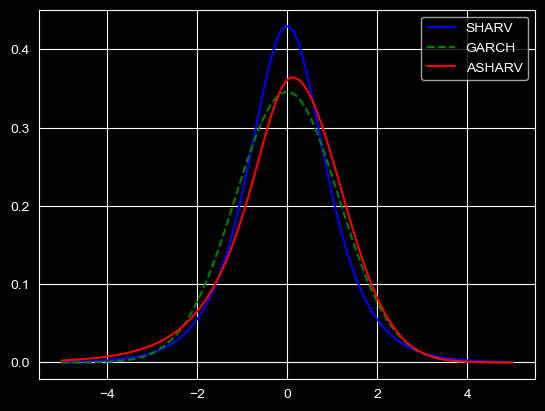

In [10]:
sharv_pdf = np.vectorize(lambda x: pdf_sharv(sharv_res.params, x, model='SHARV'))
garch_pdf = np.vectorize(lambda x: pdf_sharv([garch.params['omega'], garch.params['beta[1]'],
                                              garch.params['alpha[1]']], x, model='GARCH'))
# Notice that for ASHARV, even with symmetric normal innovation, the conditional density is left skewed with fatter
# left tail, which captures stylized facts of financial returns
asharv_pdf = np.vectorize(lambda x: pdf_sharv(asharv_res.params, x, model='ASHARV'))
x_ax = np.linspace(-5, 5, 100)
plt.plot(x_ax,sharv_pdf(x_ax), label='SHARV', color='blue')
plt.plot(x_ax,garch_pdf(x_ax), label='GARCH', color='green', linestyle='dashed')
plt.plot(x_ax,asharv_pdf(x_ax), label='ASHARV', color='red')
plt.legend()
plt.show()

Now compare the volatility nowcast, or filter. Since the true volatility is not observed. I use the daily realized volatility RV from 5-min returns as proxy since the RV converges to Integrated Volatility (IV) in the limit. Use the mean squared error and QLIKE loss function as metrix. MSE is highly sensitive to outliers which volatility models are notorious for. Hence, QLIKE is a more robust loss metric when comparing volatility performance

In [12]:
# Compare the volatility estimation with realized volatility (RV). RV for DJIA is obtained from a high frequency trading
# platform
RV = pd.read_excel('Data/rv_dj.xlsx')
RV['Date'] = pd.to_datetime(RV['DateTime'], unit='D', origin='1899-12-30')
RV.set_index('Date', inplace=True)
RV = np.sqrt(RV['Return'])

In [13]:
sharv_vol = sharv_res.filter()
asharv_vol = asharv_res.filter()
garch_vol = garch.conditional_volatility
combined_vol = pd.concat([sharv_vol['Volatility'], asharv_vol['Volatility'], garch_vol, RV], axis=1)
combined_vol.columns = ['SHARV', 'ASHARV', 'GARCH', 'RV']
combined_vol = combined_vol.dropna()

In [14]:
# Compute MSE for each model column
mse_values = ((combined_vol[['SHARV', 'ASHARV', 'GARCH']].subtract(combined_vol['RV'], axis=0))**2).mean()

# Convert results into a new DataFrame
mse_df = pd.DataFrame(mse_values, columns=['MSE'])
mse_df

,MSE
SHARV,0.093574
ASHARV,0.084537
GARCH,0.150620


In [16]:
# QLIKE formula: (y / y_hat) - log(y / y_hat) - 1
ratio = combined_vol[['SHARV', 'ASHARV', 'GARCH']].div(combined_vol['RV'], axis=0).pow(-1) # This is y / y_hat
qlike_values = (ratio - np.log(ratio) - 1).mean()

# 3. Combine into a results DataFrame
qlike_df = pd.DataFrame(qlike_values, columns=['QLIKE'])
qlike_df

,QLIKE
SHARV,0.078720
ASHARV,0.066619
GARCH,0.119889


Note that in both case (A)SHARV produce the lowest loss metrics, indicating superior volatility modelling power